# Data Loading Check with GalDataSet

This notebook demonstrates how to use the `GalDataSet` class to load data from the `Data` folder and executes a series of checks to verify the integrity of the data loading and the correctness of the properties.

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# Add project root to sys.path to import project modules
# Assuming this notebook is in VisualScripts/DataAnalysis/
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../"))
if project_root not in sys.path:
    sys.path.append(project_root)

from RawDataProcessing.GalaxyData import GalDataSet

print(f"Project root: {project_root}")


Project root: d:\PersonFiles\Codes\Project\MACNet v1


In [2]:
# Define Data Paths
# Using relative paths from project root or absolute paths
data_folder = os.path.join(project_root, "Data", "elliptical_galaxy_fiducial")
coarse_data_path = os.path.join(data_folder, "coarse")
fine_data_path = os.path.join(data_folder, "fine")

print(f"Coarse data path exists: {os.path.exists(coarse_data_path)}")
print(f"Fine data path exists: {os.path.exists(fine_data_path)}")

# Create Dataset instance
dataset = GalDataSet()

# Load data
# load_data expects a list of (path, group_index) tuples or a single path
# We load both coarse (group 0) and fine (group 1) data for testing
folders_to_load = [
    (coarse_data_path, 0),
    # (fine_data_path, 1) # Uncomment to load fine data as well, it might be large
]

print("Loading data...")
dataset.load_data(folders_to_load)
print("Data loaded.")


Coarse data path exists: True
Fine data path exists: True
Loading data...
Data loaded.


In [3]:
# Verify Data Dimensions and Types

print(f"Number of samples (dataset length): {len(dataset)}")

# Check 'x' property (Features/Snapshot data)
try:
    x_data = dataset.x
    print(f"x shape: {x_data.shape}")
    print(f"x dtype: {x_data.dtype}")
except Exception as e:
    print(f"Error accessing dataset.x: {e}")

# Check 'y' property (Target: log10(mdot_macer / mdot_edd))
try:
    y_data = dataset.y
    print(f"y shape: {y_data.shape}")
    print(f"y range: [{np.min(y_data)}, {np.max(y_data)}]")
except Exception as e:
    print(f"Error accessing dataset.y: {e}")

# Check 'time' property
try:
    time_data = dataset.time
    print(f"time shape: {time_data.shape}")
    print(f"time range: [{np.min(time_data)}, {np.max(time_data)}]")
except Exception as e:
    print(f"Error accessing dataset.time: {e}")

# Check 'groups' property
try:
    groups = dataset.groups
    print(f"groups shape: {groups.shape}")
    print(f"unique groups: {np.unique(groups)}")
    print(f"number of groups: {dataset.n_groups}")
except Exception as e:
    print(f"Error accessing dataset.groups: {e}")

# Check 'coordinate' property
try:
    coords = dataset.coordinate
    print(f"coordinate shape: {coords.shape}")
except Exception as e:
    print(f"Error accessing dataset.coordinate: {e}")


Number of samples (dataset length): 21999
x shape: (21999, 9, 8, 8)
x dtype: float32
y shape: (21999,)
y range: [nan, nan]
time shape: (21999,)
time range: [0.0001, 2.1999]
groups shape: (21999,)
unique groups: [0]
number of groups: 1
coordinate shape: (21999, 2, 8, 8)


d:\PersonFiles\Codes\Project\MACNet v1\RawDataProcessing\GalaxyData.py:516: RuntimeWarning: divide by zero encountered in log10
  return np.log10(mdot_macer / mdot_edd)


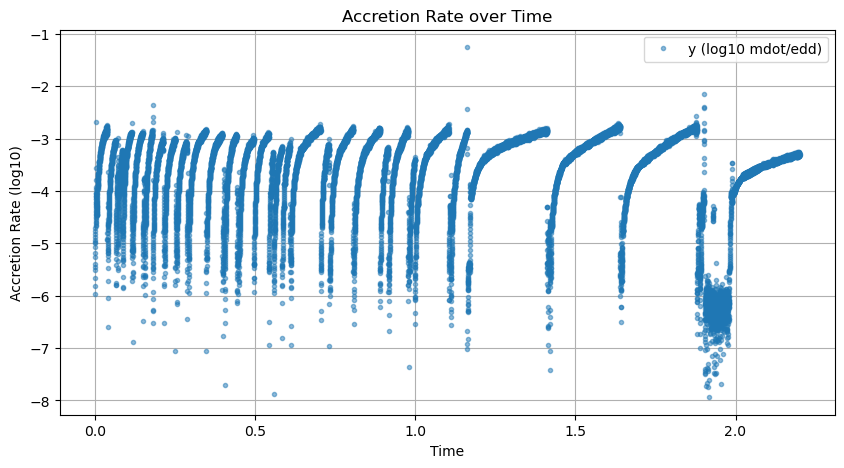

First sample shape: (9, 8, 8)


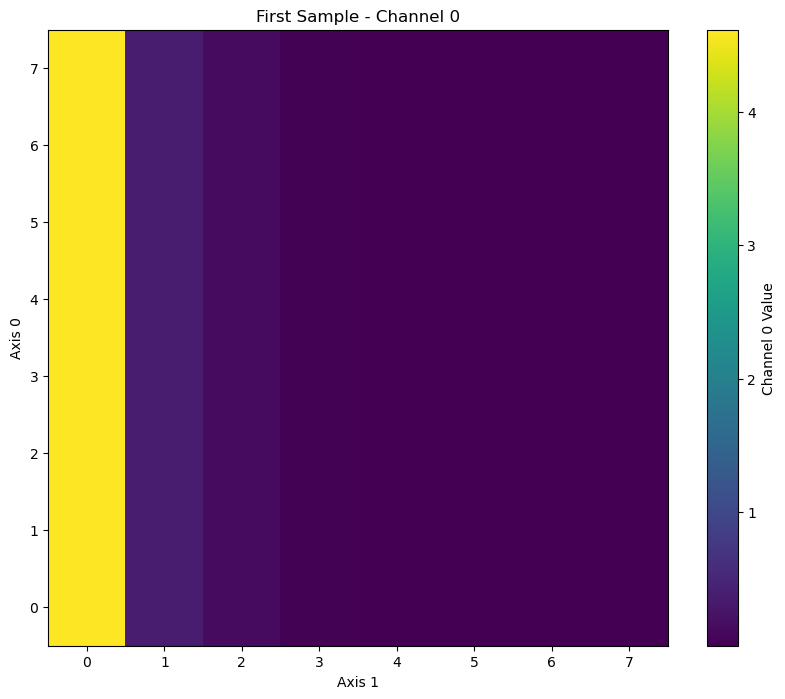

In [4]:
# Visualize Sample Data
if len(dataset) > 0:
    # Plot Time Series of 'y' (Accretion Rate)
    plt.figure(figsize=(10, 5))
    plt.plot(dataset.time, dataset.y, label='y (log10 mdot/edd)', marker='.', linestyle='none', alpha=0.5)
    plt.xlabel('Time')
    plt.ylabel('Accretion Rate (log10)')
    plt.title('Accretion Rate over Time')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Visualize one snapshot (first sample)
    # x shape is typically (channels, height, width) or (channels, theta, r)
    first_sample = dataset.x[0]
    print(f"First sample shape: {first_sample.shape}")
    
    # Assuming channel 0 is density or similar, let's plot it
    # We need to know the coordinate system to plot correctly, but imshow is a good start
    plt.figure(figsize=(10, 8))
    plt.imshow(first_sample[0], origin='lower', aspect='auto')
    plt.colorbar(label='Channel 0 Value')
    plt.title('First Sample - Channel 0')
    plt.xlabel('Axis 1')
    plt.ylabel('Axis 0')
    plt.show()
else:
    print("No data loaded to visualize.")
